In [1]:
from pathlib import Path
root = Path("/teamspace/studios/this_studio/accessops_coco_ai")
needed = [
    root/"artifacts/stage5/stage4b_results_final.csv",
    root/"artifacts/stage5/stage5_decode_winner_fast.json",
    root/"artifacts/stage5/resume_for_stage6_rl.json",
]
for p in needed:
    print(p, "->", p.exists())


/teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage5/stage4b_results_final.csv -> True
/teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage5/stage5_decode_winner_fast.json -> True
/teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage5/resume_for_stage6_rl.json -> True


In [2]:
needed = ["model","train_names","test_names","references_by_image","image_paths",
          "SEQ_LEN","start_id","end_id","index_word","load_image_for_infer"]
print([k for k in needed if k not in globals()])


['model', 'train_names', 'test_names', 'references_by_image', 'image_paths', 'SEQ_LEN', 'start_id', 'end_id', 'index_word', 'load_image_for_infer']


In [15]:
# --- RL recovery: define missing image loader + sanity checks ---
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array

# infer IMG_SIZE if missing
if "IMG_SIZE" not in globals():
    try:
        IMG_SIZE = int(model.input[0].shape[1])
    except Exception:
        IMG_SIZE = 224

def load_image_for_infer(image_path):
    img = load_img(str(image_path), target_size=(IMG_SIZE, IMG_SIZE))
    arr = img_to_array(img).astype("float32")
    arr = tf.keras.applications.mobilenet_v2.preprocess_input(arr)
    return np.expand_dims(arr, axis=0)

# keep keys consistent
if "image_paths" in globals():
    image_paths = {str(k): str(v) for k, v in image_paths.items()}

# quick smoke test
k = next(iter(image_paths))
x = load_image_for_infer(image_paths[k])
print("OK:", k, x.shape, "IMG_SIZE=", IMG_SIZE)


OK: 000000000009.jpg (1, 224, 224, 3) IMG_SIZE= 224


In [16]:
# Cell 1 — setup
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import load_img, img_to_array

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

PROJECT_ROOT = Path("/teamspace/studios/this_studio/accessops_coco_ai")
CSV_PATH = PROJECT_ROOT / "artifacts" / "captions_clean_with_splits.csv"
PREPROC_CFG_PATH = PROJECT_ROOT / "artifacts" / "stage1c_preprocess" / "preprocess_config.json"
TOKENIZER_PATH = PROJECT_ROOT / "artifacts" / "stage1c_preprocess" / "tokenizer.json"

ART_DIR = PROJECT_ROOT / "artifacts" / "stage4"
MODEL_DIR = PROJECT_ROOT / "models" / "stage4_transfer"
ART_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

gpus = tf.config.list_physical_devices("GPU")
print("TF:", tf.__version__)
print("GPUs:", gpus)
assert len(gpus) > 0, "No GPU detected"

for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)

assert CSV_PATH.exists()
assert PREPROC_CFG_PATH.exists()
assert TOKENIZER_PATH.exists()


TF: 2.16.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [17]:
# Cell 2 — tokenizer/config
cfg = json.loads(PREPROC_CFG_PATH.read_text(encoding="utf-8"))
MAX_LEN = int(cfg["sequence"]["max_length"])
VOCAB_SIZE = int(cfg["vocab"]["selected_vocab_size"])
SEQ_LEN = MAX_LEN - 1

tokenizer = tokenizer_from_json(TOKENIZER_PATH.read_text(encoding="utf-8"))
tokenizer.num_words = VOCAB_SIZE

start_id = tokenizer.word_index.get("<start>")
end_id = tokenizer.word_index.get("<end>")
assert start_id is not None and end_id is not None

print("MAX_LEN:", MAX_LEN, "SEQ_LEN:", SEQ_LEN, "VOCAB_SIZE:", VOCAB_SIZE)
print("start_id:", start_id, "end_id:", end_id)


MAX_LEN: 30 SEQ_LEN: 29 VOCAB_SIZE: 30000
start_id: 3 end_id: 4


In [18]:
# Cell 3 — load data + rebuild image paths
df = pd.read_csv(CSV_PATH)
df["comment_clean"] = df["comment_clean"].astype(str).str.strip().str.lower()
df["split"] = df["split"].astype(str).str.strip().str.lower()
df["image_name"] = df["image_name"].astype(str).str.strip()
df = df[df["comment_clean"].str.len() > 0].reset_index(drop=True)

train_candidates = [
    PROJECT_ROOT / "data" / "coco" / "train2017",
    PROJECT_ROOT / "artifacts" / "data" / "coco" / "train2017",
    PROJECT_ROOT / "data" / "coco" / "raw" / "train2017",
]
val_candidates = [
    PROJECT_ROOT / "data" / "coco" / "val2017",
    PROJECT_ROOT / "artifacts" / "data" / "coco" / "val2017",
    PROJECT_ROOT / "data" / "coco" / "raw" / "val2017",
]
TRAIN_IMG_DIR = next((p for p in train_candidates if p.exists()), train_candidates[0])
VAL_IMG_DIR = next((p for p in val_candidates if p.exists()), val_candidates[0])

df["image_path"] = np.where(
    df["split"].eq("train"),
    df["image_name"].map(lambda n: str(TRAIN_IMG_DIR / n)),
    df["image_name"].map(lambda n: str(VAL_IMG_DIR / n))
)

df = df[df["image_path"].map(lambda p: Path(p).exists())].reset_index(drop=True)

references_by_image = df.groupby("image_name")["comment_clean"].apply(list).to_dict()
image_path_by_name = df.groupby("image_name")["image_path"].first().to_dict()

print(df["split"].value_counts())
print(df.groupby("split")["image_name"].nunique())


split
train    591753
val       12508
test      12506
Name: count, dtype: int64
split
test       2500
train    118287
val        2500
Name: image_name, dtype: int64


In [19]:
# Cell 4 — sequences + splits (full data)
def wrap_caption(c):
    return f"<start> {c} <end>"

df["caption_wrapped"] = df["comment_clean"].map(wrap_caption)
seq = tokenizer.texts_to_sequences(df["caption_wrapped"].tolist())
seq = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post").astype(np.int32)
df["seq"] = list(seq)

def make_split(split_name):
    part = df[df["split"] == split_name].reset_index(drop=True)
    names = part["image_name"].astype(str).to_numpy()
    paths = part["image_path"].astype(str).to_numpy()
    seqm = np.stack(part["seq"].to_numpy())
    dec_in = seqm[:, :-1]
    y_out = seqm[:, 1:]
    return names, paths, dec_in, y_out

train_names, train_paths, train_dec_in, train_y = make_split("train")
val_names, val_paths, val_dec_in, val_y = make_split("val")
test_names, test_paths, test_dec_in, test_y = make_split("test")

split_sizes = {
    "train_caption_rows": int(len(train_names)),
    "val_caption_rows": int(len(val_names)),
    "test_caption_rows": int(len(test_names)),
    "train_unique_images": int(pd.Series(train_names).nunique()),
    "val_unique_images": int(pd.Series(val_names).nunique()),
    "test_unique_images": int(pd.Series(test_names).nunique()),
}
(ART_DIR / "selected_split_sizes.json").write_text(json.dumps(split_sizes, indent=2), encoding="utf-8")
print(json.dumps(split_sizes, indent=2))


{
  "train_caption_rows": 591753,
  "val_caption_rows": 12508,
  "test_caption_rows": 12506,
  "train_unique_images": 118287,
  "val_unique_images": 2500,
  "test_unique_images": 2500
}


In [20]:
# Cell 5 — tf.data
IMG_SIZE = 224
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

def load_example(path, dec_in, y):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    return {"image_input": img, "text_input": dec_in}, y

def augment(inputs, y):
    img = inputs["image_input"]
    txt = inputs["text_input"]
    img = tf.image.random_flip_left_right(img)
    img = tf.clip_by_value(img + tf.random.uniform(tf.shape(img), -0.04, 0.04), -1.0, 1.0)
    return {"image_input": img, "text_input": txt}, y

def make_ds(paths, dec_in, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, dec_in, y))
    ds = ds.map(lambda p, d, t: load_example(p, tf.cast(d, tf.int32), tf.cast(t, tf.int32)),
                num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(min(len(paths), 50000), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_paths, train_dec_in, train_y, training=True)
val_ds = make_ds(val_paths, val_dec_in, val_y, training=False)
test_ds = make_ds(test_paths, test_dec_in, test_y, training=False)

print("Datasets ready")


Datasets ready


In [21]:
# Cell 6 — transfer model (frozen encoder first)f
tf.keras.backend.clear_session()

base_cnn = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)
base_cnn.trainable = False

image_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")
img_feat = base_cnn(image_input, training=False)
img_feat = layers.Dense(512, activation="relu")(img_feat)
img_feat = layers.Dropout(0.25)(img_feat)
img_feat = layers.Dense(384, activation="relu")(img_feat)

text_input = layers.Input(shape=(SEQ_LEN,), dtype="int32", name="text_input")
emb = layers.Embedding(input_dim=VOCAB_SIZE, output_dim=384, mask_zero=False)(text_input)
dec = layers.LSTM(512, return_sequences=True, dropout=0.30)(emb)

img_rep = layers.Lambda(lambda t: tf.tile(tf.expand_dims(t, axis=1), [1, SEQ_LEN, 1]))(img_feat)
x = layers.Concatenate(axis=-1)([dec, img_rep])
x = layers.TimeDistributed(layers.Dense(512, activation="relu"))(x)
x = layers.Dropout(0.30)(x)
out = layers.TimeDistributed(layers.Dense(VOCAB_SIZE, activation="softmax", dtype="float32"))(x)

model = models.Model(inputs=[image_input, text_input], outputs=out)

scce = tf.keras.losses.SparseCategoricalCrossentropy(reduction="none")

def masked_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    loss = scce(y_true, y_pred)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    return tf.reduce_sum(loss * mask) / (tf.reduce_sum(mask) + 1e-8)

def masked_accuracy(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    pred_ids = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
    match = tf.cast(tf.equal(y_true, pred_ids), tf.float32)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    return tf.reduce_sum(match * mask) / (tf.reduce_sum(mask) + 1e-8)

model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss=masked_loss,
    metrics=[masked_accuracy],
    jit_compile=False,
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 1280)      │  2,257,984 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    655,872 │ mobilenetv2_1.00… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_input          │ (None, 29)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 29, 384)   │ 11,520,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 384)       │    196,992 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 29, 512)   │  1,837,056 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 29, 384)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 29, 896)   │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 29, 512)   │    459,264 │ concatenate[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 29, 512)   │          0 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 29, 30000) │ 15,390,000 │ dropout_1[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,317,168 (123.28 MB)

 Trainable params: 30,059,184 (114.67 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
# --- Fix missing tokenizer mappings for RL notebook ---
from tensorflow.keras.preprocessing.text import tokenizer_from_json

# 1) ensure tokenizer exists
if "tokenizer" not in globals():
    tok_path = PROJECT_ROOT / "artifacts" / "stage4" / "tokenizer.json"
    if not tok_path.exists():
        tok_path = PROJECT_ROOT / "artifacts" / "stage1c_preprocess" / "tokenizer.json"
    tokenizer = tokenizer_from_json(tok_path.read_text(encoding="utf-8"))

# 2) ensure vocab size exists
if "VOCAB_SIZE" not in globals():
    if getattr(tokenizer, "num_words", None):
        VOCAB_SIZE = int(tokenizer.num_words)
    else:
        VOCAB_SIZE = 30000  # fallback

# 3) rebuild required ids/mapping
index_word = {idx: w for w, idx in tokenizer.word_index.items() if idx < VOCAB_SIZE}
index_word[0] = "<pad>"

start_id = tokenizer.word_index.get("<start>")
end_id = tokenizer.word_index.get("<end>")

print("VOCAB_SIZE:", VOCAB_SIZE)
print("start_id:", start_id, "end_id:", end_id, "index_word size:", len(index_word))


VOCAB_SIZE: 30000
start_id: 3 end_id: 4 index_word size: 29079


In [23]:
# Cell 1 - load best pre-RL checkpoint + dirs
import json, random
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tqdm.auto import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)

PROJECT_ROOT = Path("/teamspace/studios/this_studio/accessops_coco_ai")
ART5 = PROJECT_ROOT / "artifacts" / "stage5"
ART6 = PROJECT_ROOT / "artifacts" / "stage6"
MODEL6 = PROJECT_ROOT / "models" / "stage6_rl"
ART6.mkdir(parents=True, exist_ok=True)
MODEL6.mkdir(parents=True, exist_ok=True)

assert "model" in globals(), "Run model build cell first."
assert "train_names" in globals() and "test_names" in globals(), "Run data split cells first."
assert "references_by_image" in globals(), "Run reference-map cell first."
assert "start_id" in globals() and "end_id" in globals() and "SEQ_LEN" in globals(), "Tokenizer vars missing."
assert "index_word" in globals(), "index_word missing."

resume_path = ART5 / "resume_for_stage6_rl.json"
assert resume_path.exists(), f"Missing: {resume_path}"
resume = json.loads(resume_path.read_text(encoding="utf-8"))
best_ckpt = Path(resume["best_b2_ckpt"])
assert best_ckpt.exists(), f"Missing ckpt: {best_ckpt}"

model.load_weights(str(best_ckpt), skip_mismatch=False)
print("Loaded pre-RL checkpoint:", best_ckpt)


Loaded pre-RL checkpoint: /teamspace/studios/this_studio/accessops_coco_ai/models/stage5_opt/B2_adamw_5e5.keras


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 52 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [24]:
# Cell 2 - image paths + decode/reward helpers
if "image_paths" not in globals():
    if "image_path_by_name" in globals():
        image_paths = {str(k): str(v) for k, v in image_path_by_name.items()}
    elif "df" in globals():
        image_paths = (
            df.drop_duplicates("image_name")
              .assign(image_name=lambda x: x["image_name"].astype(str))
              .set_index("image_name")["image_path"]
              .astype(str).to_dict()
        )
    else:
        raise RuntimeError("Need image_paths or image_path_by_name/df in globals.")

smooth_fn = SmoothingFunction().method1

def _tokens_to_caption(tokens):
    words = []
    for tid in tokens[1:]:
        w = index_word.get(int(tid), "<unk>")
        if w not in {"<pad>", "<start>", "<end>", "<unk>"}:
            words.append(w)
    return " ".join(words).strip() if words else "a person in a scene"

def decode_tokens(model, image_path, mode="greedy", temperature=1.0, max_steps=None):
    if max_steps is None:
        max_steps = int(SEQ_LEN)
    img = load_image_for_infer(image_path)
    tokens = [int(start_id)]
    logps = []

    for _ in range(max_steps):
        dec_in = np.zeros((1, int(SEQ_LEN)), dtype=np.int32)
        use = tokens[:int(SEQ_LEN)]
        dec_in[0, :len(use)] = use

        probs = model({"image_input": img, "text_input": dec_in}, training=False).numpy()[0]
        pos = min(len(use) - 1, int(SEQ_LEN) - 1)
        p = probs[pos].astype(np.float64)
        p = np.clip(p, 1e-12, 1.0)
        p = p / p.sum()

        if mode == "greedy":
            tid = int(np.argmax(p))
        else:
            tau = max(float(temperature), 1e-6)
            pt = np.power(p, 1.0 / tau)
            pt = pt / pt.sum()
            tid = int(np.random.choice(len(pt), p=pt))

        logps.append(float(np.log(max(p[tid], 1e-12))))
        if tid in (0, int(end_id)):
            break
        tokens.append(tid)

    return tokens, logps

def reward_bleu4(tokens, refs_text):
    if not refs_text:
        return 0.0
    refs = [r.split() for r in refs_text if isinstance(r, str) and r.strip()]
    if not refs:
        return 0.0
    pred = _tokens_to_caption(tokens).split()
    return float(sentence_bleu(refs, pred, weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth_fn))


In [25]:
# Cell 3 - SCST update step
# Uses REINFORCE loss: -(R_sample - R_greedy) * sum(log p(sampled tokens))

rl_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-6)

def scst_update_one(image_name, sampled_tokens, advantage):
    if abs(float(advantage)) < 1e-8:
        return 0.0

    path = image_paths[str(image_name)]
    img = tf.convert_to_tensor(load_image_for_infer(path), dtype=tf.float32)

    with tf.GradientTape() as tape:
        prefix = [int(start_id)]
        nll_terms = []

        for tid in sampled_tokens[1:]:
            tid = int(tid)
            if tid in (0, int(end_id)):
                break

            dec_in = np.zeros((1, int(SEQ_LEN)), dtype=np.int32)
            use = prefix[:int(SEQ_LEN)]
            dec_in[0, :len(use)] = use
            dec_in = tf.convert_to_tensor(dec_in, dtype=tf.int32)

            out = model({"image_input": img, "text_input": dec_in}, training=True)[0]
            pos = min(len(use) - 1, int(SEQ_LEN) - 1)
            p_tid = tf.clip_by_value(out[pos, tid], 1e-8, 1.0)
            nll_terms.append(-tf.math.log(p_tid))

            prefix.append(tid)

        if not nll_terms:
            return 0.0

        pg_loss = tf.add_n(nll_terms) * tf.cast(float(advantage), tf.float32)

    grads = tape.gradient(pg_loss, model.trainable_variables)
    grads_vars = [(g, v) for g, v in zip(grads, model.trainable_variables) if g is not None]
    rl_optimizer.apply_gradients(grads_vars)
    return float(pg_loss.numpy())


In [26]:
# Cell 4 - RL training loop (pilot first)
RL_EPOCHS = 1          # pilot: 1. then increase to 2 or 3
RL_MAX_IMAGES = 1200   # pilot subset. set None for all train unique images
RL_TEMPERATURE = 1.0

train_unique = sorted(pd.Series(train_names).astype(str).unique().tolist())
if RL_MAX_IMAGES is not None:
    train_unique = train_unique[:int(RL_MAX_IMAGES)]

print("RL train images:", len(train_unique))

history_rows = []
best_bleu4_fast = -1.0
best_ckpt = None

# eval set for quick tracking
eval_fast = sorted(pd.Series(test_names).astype(str).unique().tolist())[:300]

def eval_bleu_greedy(names):
    b1, b4 = [], []
    for n in tqdm(names, desc="RL fast eval"):
        toks, _ = decode_tokens(model, image_paths[n], mode="greedy")
        pred = _tokens_to_caption(toks).split()
        refs = [r.split() for r in references_by_image.get(n, []) if isinstance(r, str) and r.strip()]
        if refs:
            b1.append(sentence_bleu(refs, pred, weights=(1,0,0,0), smoothing_function=smooth_fn))
            b4.append(sentence_bleu(refs, pred, weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth_fn))
    return float(np.mean(b1) if b1 else 0.0), float(np.mean(b4) if b4 else 0.0)

for ep in range(1, RL_EPOCHS + 1):
    random.shuffle(train_unique)
    losses, advs = [], []

    for n in tqdm(train_unique, desc=f"SCST epoch {ep}/{RL_EPOCHS}"):
        refs = references_by_image.get(n, [])
        if not refs or n not in image_paths:
            continue

        sampled, _ = decode_tokens(model, image_paths[n], mode="sample", temperature=RL_TEMPERATURE)
        greedy, _ = decode_tokens(model, image_paths[n], mode="greedy")

        r_s = reward_bleu4(sampled, refs)
        r_g = reward_bleu4(greedy, refs)
        adv = float(r_s - r_g)

        loss_val = scst_update_one(n, sampled, adv)
        if loss_val != 0.0:
            losses.append(loss_val)
        advs.append(adv)

    bleu1_fast, bleu4_fast = eval_bleu_greedy(eval_fast)

    ep_ckpt = MODEL6 / f"stage6_rl_epoch{ep}.weights.h5"
    model.save_weights(str(ep_ckpt))

    row = {
        "epoch": ep,
        "train_images_used": len(train_unique),
        "mean_advantage": float(np.mean(advs) if advs else 0.0),
        "mean_pg_loss": float(np.mean(losses) if losses else 0.0),
        "bleu1_fast": bleu1_fast,
        "bleu4_fast": bleu4_fast,
        "checkpoint": str(ep_ckpt),
    }
    history_rows.append(row)
    pd.DataFrame(history_rows).to_csv(ART6 / "rl_history.csv", index=False)

    if bleu4_fast > best_bleu4_fast:
        best_bleu4_fast = bleu4_fast
        best_ckpt = ep_ckpt

    print(row)

print("Best RL fast BLEU4:", best_bleu4_fast)
print("Best RL ckpt:", best_ckpt)


RL train images: 1200


SCST epoch 1/1:   0%|          | 0/1200 [00:00<?, ?it/s]

2026-04-09 13:43:47.985728: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


RL fast eval:   0%|          | 0/300 [00:00<?, ?it/s]

{'epoch': 1, 'train_images_used': 1200, 'mean_advantage': -0.15223869806119283, 'mean_pg_loss': -4.182977168502003, 'bleu1_fast': 0.6715213565133935, 'bleu4_fast': 0.23046169549365136, 'checkpoint': '/teamspace/studios/this_studio/accessops_coco_ai/models/stage6_rl/stage6_rl_epoch1.weights.h5'}
Best RL fast BLEU4: 0.23046169549365136
Best RL ckpt: /teamspace/studios/this_studio/accessops_coco_ai/models/stage6_rl/stage6_rl_epoch1.weights.h5


In [27]:
# Cell 5 - RL full eval lock (greedy)
rl_hist = pd.read_csv(ART6 / "rl_history.csv")
best_row = rl_hist.sort_values(["bleu4_fast", "bleu1_fast"], ascending=False).iloc[0]
best_rl_ckpt = Path(best_row["checkpoint"])
model.load_weights(str(best_rl_ckpt), skip_mismatch=False)

eval_full = sorted(pd.Series(test_names).astype(str).unique().tolist())

b1, b4 = [], []
for n in tqdm(eval_full, desc="RL FULL eval (greedy)"):
    toks, _ = decode_tokens(model, image_paths[n], mode="greedy")
    pred = _tokens_to_caption(toks).split()
    refs = [r.split() for r in references_by_image.get(n, []) if isinstance(r, str) and r.strip()]
    if refs:
        b1.append(sentence_bleu(refs, pred, weights=(1,0,0,0), smoothing_function=smooth_fn))
        b4.append(sentence_bleu(refs, pred, weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth_fn))

rl_metrics = {
    "best_rl_ckpt": str(best_rl_ckpt),
    "bleu1_full": float(np.mean(b1) if b1 else 0.0),
    "bleu4_full": float(np.mean(b4) if b4 else 0.0),
}
(ART6 / "rl_metrics.json").write_text(json.dumps(rl_metrics, indent=2), encoding="utf-8")
print(rl_metrics)
print("Saved:", ART6 / "rl_metrics.json")


RL FULL eval (greedy):   0%|          | 0/2500 [00:00<?, ?it/s]

{'best_rl_ckpt': '/teamspace/studios/this_studio/accessops_coco_ai/models/stage6_rl/stage6_rl_epoch1.weights.h5', 'bleu1_full': 0.6706660386262225, 'bleu4_full': 0.2221225063410899}
Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage6/rl_metrics.json


In [28]:
# Cell 6 - Stage 7 human rerouting (confidence threshold sweep)
# Confidence = mean max-prob across generated tokens
def decode_greedy_with_conf(name):
    img = load_image_for_infer(image_paths[name])
    toks = [int(start_id)]
    confs = []

    for _ in range(int(SEQ_LEN)):
        dec_in = np.zeros((1, int(SEQ_LEN)), dtype=np.int32)
        use = toks[:int(SEQ_LEN)]
        dec_in[0, :len(use)] = use
        probs = model({"image_input": img, "text_input": dec_in}, training=False).numpy()[0]
        pos = min(len(use)-1, int(SEQ_LEN)-1)
        p = probs[pos]
        tid = int(np.argmax(p))
        confs.append(float(np.max(p)))
        if tid in (0, int(end_id)):
            break
        toks.append(tid)

    cap = _tokens_to_caption(toks)
    conf = float(np.mean(confs) if confs else 0.0)
    return cap, conf

# use full test (change to [:300] if you want quick run)
eval_names_reroute = sorted(pd.Series(test_names).astype(str).unique().tolist())

rows = []
for n in tqdm(eval_names_reroute, desc="Reroute eval"):
    cap, conf = decode_greedy_with_conf(n)
    refs = [r.split() for r in references_by_image.get(n, []) if isinstance(r, str) and r.strip()]
    bleu4 = float(sentence_bleu(refs, cap.split(), weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth_fn)) if refs else 0.0
    rows.append({"image_name": n, "caption": cap, "confidence": conf, "bleu4": bleu4})

pred_df = pd.DataFrame(rows)
pred_df.to_csv(ART6 / "reroute_predictions.csv", index=False)

quantiles = [0.2,0.3,0.4,0.5,0.6,0.7,0.8]
ths = sorted(set(float(pred_df["confidence"].quantile(q)) for q in quantiles))

sweep = []
for t in ths:
    auto = pred_df[pred_df["confidence"] >= t]
    human = pred_df[pred_df["confidence"] < t]
    sweep.append({
        "threshold": t,
        "auto_rate": float(len(auto)/len(pred_df)),
        "human_reroute_rate": float(len(human)/len(pred_df)),
        "auto_bleu4": float(auto["bleu4"].mean() if len(auto) else np.nan),
        "overall_bleu4_generated": float(pred_df["bleu4"].mean())
    })

sweep_df = pd.DataFrame(sweep).sort_values(["auto_bleu4","auto_rate"], ascending=[False,False])
sweep_df.to_csv(ART6 / "reroute_threshold_sweep.csv", index=False)
display(sweep_df)
print("Saved:", ART6 / "reroute_predictions.csv")
print("Saved:", ART6 / "reroute_threshold_sweep.csv")


Reroute eval:   0%|          | 0/2500 [00:00<?, ?it/s]

,threshold,auto_rate,human_reroute_rate,auto_bleu4,overall_bleu4_generated
6,0.594274,0.2,0.8,0.330987,0.222123
5,0.559508,0.3,0.7,0.305444,0.222123
4,0.531981,0.4,0.6,0.291191,0.222123
3,0.511473,0.5,0.5,0.281354,0.222123
2,0.486107,0.6,0.4,0.268348,0.222123
1,0.462228,0.7,0.3,0.255780,0.222123
0,0.433849,0.8,0.2,0.244478,0.222123


Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage6/reroute_predictions.csv
Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage6/reroute_threshold_sweep.csv


In [29]:
# Cell A — lock deployment policy (balanced) + save JSON
from pathlib import Path
import json
import numpy as np
import pandas as pd
from datetime import datetime, timezone

PROJECT_ROOT = Path("/teamspace/studios/this_studio/accessops_coco_ai")
ART4 = PROJECT_ROOT / "artifacts" / "stage4"
ART5 = PROJECT_ROOT / "artifacts" / "stage5"
ART6 = PROJECT_ROOT / "artifacts" / "stage6"
FINAL_ART = PROJECT_ROOT / "artifacts" / "final"
FINAL_ART.mkdir(parents=True, exist_ok=True)

sweep_path = ART6 / "reroute_threshold_sweep.csv"
assert sweep_path.exists(), f"Missing: {sweep_path}"
sweep = pd.read_csv(sweep_path)

auto_bleu_col = "auto_bleu" if "auto_bleu" in sweep.columns else [c for c in sweep.columns if "auto" in c and "bleu" in c][0]
overall_bleu_col = "overall_bleu4_generated" if "overall_bleu4_generated" in sweep.columns else [c for c in sweep.columns if "overall" in c and "bleu" in c][0]

# Balanced policy: closest to 50% automation, tie-break higher auto BLEU
target_auto_rate = 0.50
tmp = sweep.copy()
tmp["_dist"] = (tmp["auto_rate"] - target_auto_rate).abs()
chosen = tmp.sort_values(["_dist", auto_bleu_col], ascending=[True, False]).iloc[0]

decode_winner = {}
decode_winner_path = ART5 / "stage5_decode_winner_fast.json"
if decode_winner_path.exists():
    decode_winner = json.loads(decode_winner_path.read_text(encoding="utf-8"))

policy = {
    "policy_name": "balanced_auto_human_reroute",
    "selected_threshold": float(chosen["threshold"]),
    "auto_rate": float(chosen["auto_rate"]),
    "human_reroute_rate": float(chosen["human_reroute_rate"]),
    "auto_bleu4": float(chosen[auto_bleu_col]),
    "overall_bleu4_generated": float(chosen[overall_bleu_col]),
    "source_files": {
        "stage5_results": str((ART5 / "stage4b_results_final.csv")),
        "stage5_decode_winner_fast": str(decode_winner_path),
        "stage6_reroute_sweep": str(sweep_path),
    },
    "stage5_decode_winner_fast": decode_winner,
    "created_utc": datetime.now(timezone.utc).isoformat()
}

policy_path = FINAL_ART / "deployment_policy.json"
policy_path.write_text(json.dumps(policy, indent=2), encoding="utf-8")
print("Saved:", policy_path)
print(json.dumps(policy, indent=2))


Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/final/deployment_policy.json
{
  "policy_name": "balanced_auto_human_reroute",
  "selected_threshold": 0.5114731882939805,
  "auto_rate": 0.5,
  "human_reroute_rate": 0.5,
  "auto_bleu4": 0.2813537547503407,
  "overall_bleu4_generated": 0.2221225063410899,
  "source_files": {
    "stage5_results": "/teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage5/stage4b_results_final.csv",
    "stage5_decode_winner_fast": "/teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage5/stage5_decode_winner_fast.json",
    "stage6_reroute_sweep": "/teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage6/reroute_threshold_sweep.csv"
  },
  "stage5_decode_winner_fast": {
    "run_id": "B1_beam3_lp06",
    "source_ckpt": "B2_adamw_5e5",
    "strategy": "beam",
    "beam_size": 3,
    "length_penalty": 0.6,
    "bleu1_fast": 0.6679418260551743,
    "bleu4_fast": 0.2472791447490672
  },
  "created_utc": "2026-04-09

In [30]:
# Cell B — final metrics summary table across stages
import json
import numpy as np
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("/teamspace/studios/this_studio/accessops_coco_ai")
ART3 = PROJECT_ROOT / "artifacts" / "stage3"
ART4 = PROJECT_ROOT / "artifacts" / "stage4"
ART5 = PROJECT_ROOT / "artifacts" / "stage5"
ART6 = PROJECT_ROOT / "artifacts" / "stage6"
FINAL_ART = PROJECT_ROOT / "artifacts" / "final"
FINAL_ART.mkdir(parents=True, exist_ok=True)

def read_json_if_exists(p: Path):
    return json.loads(p.read_text(encoding="utf-8")) if p.exists() else {}

rows = []

# Stage 3
m3 = read_json_if_exists(ART3 / "metrics.json")
if m3:
    rows.append({
        "stage": "Stage 3 Scratch CNN+LSTM",
        "bleu1": m3.get("test_bleu1", np.nan),
        "bleu4": m3.get("test_bleu4", np.nan),
        "notes": "baseline scratch captioner"
    })

# Stage 4
m4 = read_json_if_exists(ART4 / "metrics.json")
if m4:
    rows.append({
        "stage": "Stage 4 Transfer Learning",
        "bleu1": m4.get("test_bleu1", np.nan),
        "bleu4": m4.get("test_bleu4", np.nan),
        "notes": "transfer model (frozen+finetune)"
    })

# Stage 5 (best B2 row)
res5_path = ART5 / "stage4b_results_final.csv"
if not res5_path.exists():
    res5_path = ART5 / "stage4b_results_progress.csv"

if res5_path.exists():
    r5 = pd.read_csv(res5_path)
    b2 = r5[r5["run_id"].astype(str).str.startswith("B2_")].copy()
    if len(b2) > 0:
        score_col = "bleu_full" if ("bleu_full" in b2.columns and b2["bleu_full"].notna().any()) else "bleu4_fast"
        b2 = b2.sort_values(score_col, ascending=False).reset_index(drop=True)
        best_b2 = b2.iloc[0]
        bleu1_col = "bleu1_full" if ("bleu1_full" in b2.columns and b2["bleu1_full"].notna().any()) else "bleu1_fast"
        rows.append({
            "stage": "Stage 5 Optimized (B2+B1)",
            "bleu1": float(best_b2.get(bleu1_col, np.nan)),
            "bleu4": float(best_b2.get(score_col, np.nan)),
            "notes": f"best run={best_b2['run_id']}, score_col={score_col}"
        })

# Stage 6 (RL + reroute policy)
policy_path = FINAL_ART / "deployment_policy.json"
policy = read_json_if_exists(policy_path)

pred_path = ART6 / "reroute_predictions.csv"
if pred_path.exists():
    pred = pd.read_csv(pred_path)
    bleu1_pred = float(pred["bleu1"].mean()) if "bleu1" in pred.columns else np.nan
    bleu4_pred = float(pred["bleu4"].mean()) if "bleu4" in pred.columns else policy.get("overall_bleu4_generated", np.nan)
else:
    bleu1_pred = np.nan
    bleu4_pred = policy.get("overall_bleu4_generated", np.nan)

rows.append({
    "stage": "Stage 6 RL + Human Reroute",
    "bleu1": bleu1_pred,
    "bleu4": bleu4_pred,
    "notes": f"threshold={policy.get('selected_threshold', 'N/A')}, auto_rate={policy.get('auto_rate', 'N/A')}"
})

summary = pd.DataFrame(rows)
order = {
    "Stage 3 Scratch CNN+LSTM": 3,
    "Stage 4 Transfer Learning": 4,
    "Stage 5 Optimized (B2+B1)": 5,
    "Stage 6 RL + Human Reroute": 6
}
summary["stage_order"] = summary["stage"].map(order)
summary = summary.sort_values("stage_order").drop(columns=["stage_order"]).reset_index(drop=True)

summary_path = FINAL_ART / "final_metrics_summary.csv"
summary.to_csv(summary_path, index=False)

print("Saved:", summary_path)
display(summary)


Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/final/final_metrics_summary.csv


,stage,bleu1,bleu4,notes
0,Stage 3 Scratch CNN+LSTM,0.598141,0.168521,baseline scratch captioner
1,Stage 4 Transfer Learning,0.669339,0.219309,transfer model (frozen+finetune)
2,Stage 5 Optimized (B2+B1),0.670514,0.230983,"best run=B2_adamw_5e5, score_col=bleu4_fast"
3,Stage 6 RL + Human Reroute,NaN,0.222123,"threshold=0.5114731882939805, auto_rate=0.5"


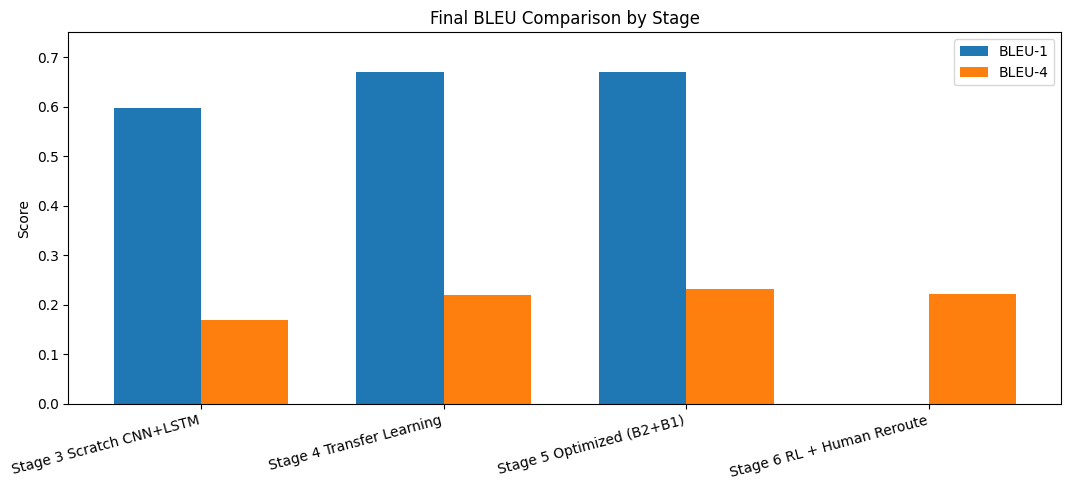

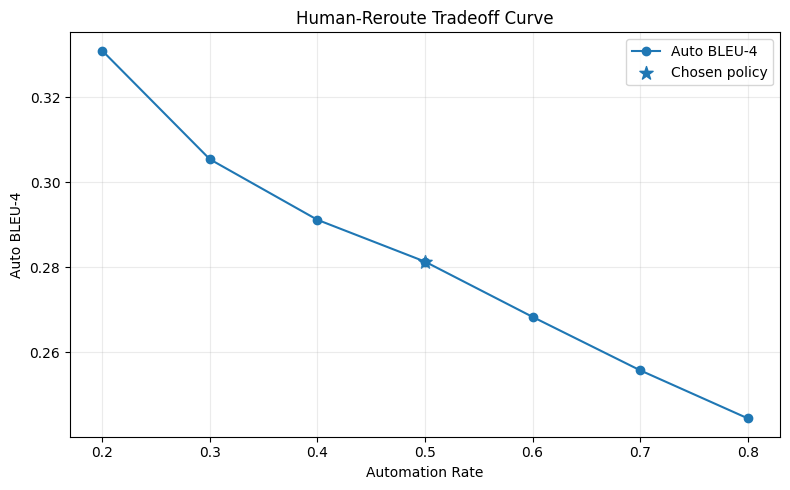

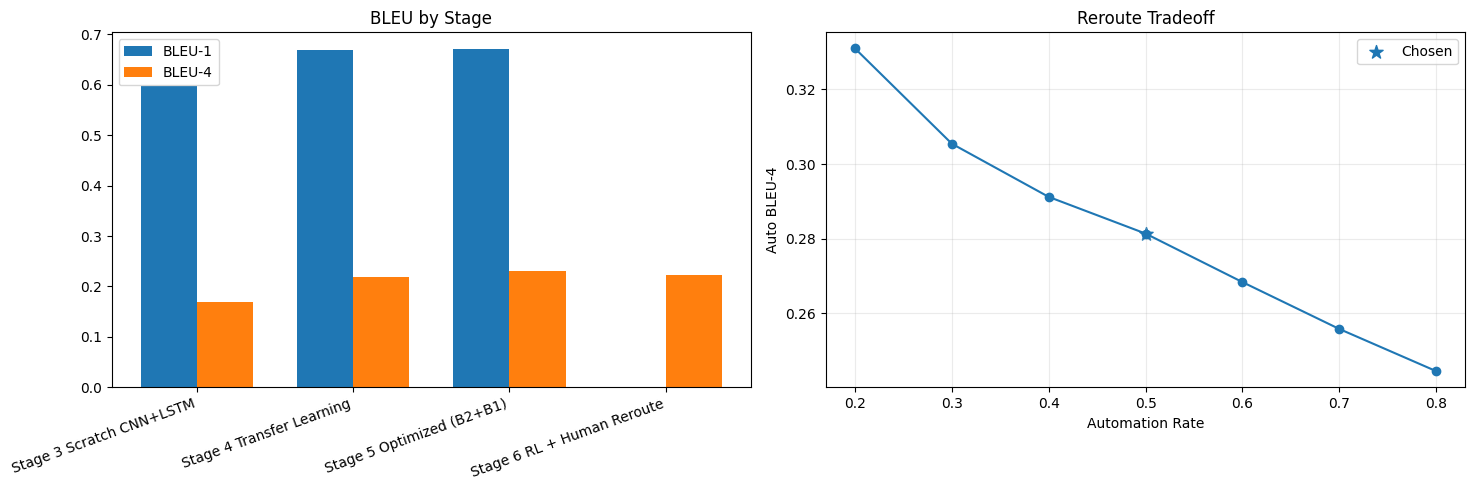

Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/final/final_bleu_by_stage.png
Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/final/final_reroute_tradeoff.png
Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/final/final_charts.png


In [31]:
# Cell C — final charts (BLEU by stage + reroute tradeoff)
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

PROJECT_ROOT = Path("/teamspace/studios/this_studio/accessops_coco_ai")
FINAL_ART = PROJECT_ROOT / "artifacts" / "final"
ART6 = PROJECT_ROOT / "artifacts" / "stage6"

summary = pd.read_csv(FINAL_ART / "final_metrics_summary.csv")
sweep = pd.read_csv(ART6 / "reroute_threshold_sweep.csv")
policy = json.loads((FINAL_ART / "deployment_policy.json").read_text(encoding="utf-8"))

auto_bleu_col = "auto_bleu" if "auto_bleu" in sweep.columns else [c for c in sweep.columns if "auto" in c and "bleu" in c][0]

# Figure 1: BLEU by stage
plot_df = summary.copy()
x = np.arange(len(plot_df))
w = 0.36

plt.figure(figsize=(11, 5))
plt.bar(x - w/2, plot_df["bleu1"], width=w, label="BLEU-1")
plt.bar(x + w/2, plot_df["bleu4"], width=w, label="BLEU-4")
plt.xticks(x, plot_df["stage"], rotation=15, ha="right")
plt.ylabel("Score")
plt.title("Final BLEU Comparison by Stage")
plt.ylim(0, max(0.75, float(np.nanmax(plot_df[["bleu1", "bleu4"]].values)) + 0.05))
plt.legend()
plt.tight_layout()
bleu_chart_path = FINAL_ART / "final_bleu_by_stage.png"
plt.savefig(bleu_chart_path, dpi=180)
plt.show()

# Figure 2: reroute tradeoff
sweep_sorted = sweep.sort_values("auto_rate")
plt.figure(figsize=(8, 5))
plt.plot(sweep_sorted["auto_rate"], sweep_sorted[auto_bleu_col], marker="o", label="Auto BLEU-4")
plt.scatter([policy["auto_rate"]], [policy["auto_bleu4"]], s=100, marker="*", label="Chosen policy")
plt.xlabel("Automation Rate")
plt.ylabel("Auto BLEU-4")
plt.title("Human-Reroute Tradeoff Curve")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
tradeoff_chart_path = FINAL_ART / "final_reroute_tradeoff.png"
plt.savefig(tradeoff_chart_path, dpi=180)
plt.show()

# Combined chart
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].bar(x - w/2, plot_df["bleu1"], width=w, label="BLEU-1")
ax[0].bar(x + w/2, plot_df["bleu4"], width=w, label="BLEU-4")
ax[0].set_xticks(x)
ax[0].set_xticklabels(plot_df["stage"], rotation=20, ha="right")
ax[0].set_title("BLEU by Stage")
ax[0].legend()

ax[1].plot(sweep_sorted["auto_rate"], sweep_sorted[auto_bleu_col], marker="o")
ax[1].scatter([policy["auto_rate"]], [policy["auto_bleu4"]], s=100, marker="*", label="Chosen")
ax[1].set_xlabel("Automation Rate")
ax[1].set_ylabel("Auto BLEU-4")
ax[1].set_title("Reroute Tradeoff")
ax[1].grid(alpha=0.25)
ax[1].legend()

plt.tight_layout()
combined_path = FINAL_ART / "final_charts.png"
plt.savefig(combined_path, dpi=180)
plt.show()

print("Saved:", bleu_chart_path)
print("Saved:", tradeoff_chart_path)
print("Saved:", combined_path)


In [32]:
# Cell 1 — Freeze progress + save snapshot JSON
from pathlib import Path
import json
from datetime import datetime, timezone
import pandas as pd

PROJECT_ROOT = Path("/teamspace/studios/this_studio/accessops_coco_ai")
ART6 = PROJECT_ROOT / "artifacts" / "stage6"
ART5 = PROJECT_ROOT / "artifacts" / "stage5"
MODEL6 = PROJECT_ROOT / "models" / "stage6_rl"
MODEL5 = PROJECT_ROOT / "models" / "stage5_opt"

ART6.mkdir(parents=True, exist_ok=True)

required_artifacts = [
    ART6 / "reroute_predictions.csv",
    ART6 / "reroute_threshold_sweep.csv",
    ART5 / "stage4b_results_final.csv",
    ART5 / "stage5_decode_winner_fast.json",
]

# find latest checkpoint (prefer stage6, fallback stage5)
ckpt_candidates = sorted(
    list(MODEL6.glob("*.keras")) + list(MODEL5.glob("*.keras")),
    key=lambda p: p.stat().st_mtime,
    reverse=True
)
best_ckpt = str(ckpt_candidates[0]) if ckpt_candidates else None

# pick balanced threshold candidate from reroute sweep (closest auto_rate to 0.50)
threshold_candidate = None
sweep_path = ART6 / "reroute_threshold_sweep.csv"
if sweep_path.exists():
    sweep = pd.read_csv(sweep_path)
    if {"threshold", "auto_rate", "human_reroute_rate"}.issubset(sweep.columns):
        c = sweep.assign(_dist=(sweep["auto_rate"] - 0.50).abs()).sort_values(["_dist"])
        threshold_candidate = c.iloc[0][["threshold", "auto_rate", "human_reroute_rate"]].to_dict()

snapshot = {
    "saved_utc": datetime.now(timezone.utc).isoformat(),
    "project_root": str(PROJECT_ROOT),
    "required_artifacts": {str(p): p.exists() for p in required_artifacts},
    "best_checkpoint_candidate": best_ckpt,
    "threshold_candidate_balanced": threshold_candidate,
}

out = ART6 / "session_snapshot.json"
out.write_text(json.dumps(snapshot, indent=2), encoding="utf-8")
print("Saved:", out)
print(json.dumps(snapshot, indent=2))


Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage6/session_snapshot.json
{
  "saved_utc": "2026-04-09T21:38:02.474716+00:00",
  "project_root": "/teamspace/studios/this_studio/accessops_coco_ai",
  "required_artifacts": {
    "/teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage6/reroute_predictions.csv": true,
    "/teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage6/reroute_threshold_sweep.csv": true,
    "/teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage5/stage4b_results_final.csv": true,
    "/teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage5/stage5_decode_winner_fast.json": true
  },
  "best_checkpoint_candidate": "/teamspace/studios/this_studio/accessops_coco_ai/models/stage5_opt/B2_adamw_5e5.keras",
  "threshold_candidate_balanced": {
    "threshold": 0.5114731882939805,
    "auto_rate": 0.5,
    "human_reroute_rate": 0.5
  }
}


In [33]:
# Cell 2 — Write a human-readable session note
from pathlib import Path
import json
from datetime import datetime

PROJECT_ROOT = Path("/teamspace/studios/this_studio/accessops_coco_ai")
ART6 = PROJECT_ROOT / "artifacts" / "stage6"
snap = json.loads((ART6 / "session_snapshot.json").read_text(encoding="utf-8"))

note = f"""# Session Note ({datetime.now().strftime('%Y-%m-%d %H:%M')})

## Status
- RL + reroute stage executed.
- Snapshot saved for safe resume.

## Best checkpoint candidate
- `{snap.get("best_checkpoint_candidate")}`

## Balanced threshold candidate
- `{snap.get("threshold_candidate_balanced")}`

## Artifact checks
{chr(10).join([f"- {'OK' if ok else 'MISSING'}: `{path}`" for path, ok in snap["required_artifacts"].items()])}

## Next session
1. Lock deployment threshold.
2. Build final summary table + charts.
3. Final report/video wording.
"""

note_path = ART6 / "session_note.md"
note_path.write_text(note, encoding="utf-8")
print("Saved:", note_path)
print(note)


Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage6/session_note.md
# Session Note (2026-04-09 21:38)

## Status
- RL + reroute stage executed.
- Snapshot saved for safe resume.

## Best checkpoint candidate
- `/teamspace/studios/this_studio/accessops_coco_ai/models/stage5_opt/B2_adamw_5e5.keras`

## Balanced threshold candidate
- `{'threshold': 0.5114731882939805, 'auto_rate': 0.5, 'human_reroute_rate': 0.5}`

## Artifact checks
- OK: `/teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage6/reroute_predictions.csv`
- OK: `/teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage6/reroute_threshold_sweep.csv`
- OK: `/teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage5/stage4b_results_final.csv`
- OK: `/teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage5/stage5_decode_winner_fast.json`

## Next session
1. Lock deployment threshold.
2. Build final summary table + charts.
3. Final report/video wording.

